# Phase 8 - Model Explainability

## Objective

Explain the final churn prediction model using SHAP.

The selected final model is:

```text
src/models/final_model.pkl
```

This phase focuses on understanding **why** the model predicts churn, not retraining the model.


In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import shap


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.explainability.shap_utils import (
    explain_binary_tree_model,
    sample_features,
    top_shap_features,
)

MODEL_PATH = PROJECT_ROOT / "src" / "models" / "final_model.pkl"
X_TEST_PATH = PROJECT_ROOT / "data" / "processed" / "X_test_processed.csv"
Y_TEST_PATH = PROJECT_ROOT / "data" / "processed" / "y_test.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures directory:", FIGURES_DIR)


Project root: /Users/anshumaansharma0404gmail.com/Desktop/ML-Strugles/customer-churn-prediction
Figures directory: /Users/anshumaansharma0404gmail.com/Desktop/ML-Strugles/customer-churn-prediction/reports/figures


## 8.1 Why Explainability Matters

Churn prediction is used to guide business action. A high-risk prediction should not be treated as a black box.

Explainability helps answer:

- Which features are most responsible for churn predictions?
- Why was one customer marked as high risk?
- Can business users trust the model's behavior?

SHAP is useful because it assigns each feature a contribution value for a model prediction.


## 8.2 Load Final Model and Processed Test Data

The model expects already processed features, so this notebook uses the saved processed test set from Phase 3.


In [3]:
final_model = joblib.load(MODEL_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

print("Model type:", type(final_model).__name__)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


Model type: XGBClassifier
X_test shape: (2026, 37)
y_test shape: (2026,)


## 8.3 Compute SHAP Values

SHAP can be computationally expensive, so a stable sample of the test set is used for global plots.


In [4]:
X_explain = sample_features(X_test, sample_size=500, random_state=42)
shap_values = explain_binary_tree_model(final_model, X_explain)

print("Explanation rows:", shap_values.values.shape[0])
print("Explanation features:", shap_values.values.shape[1])


Explanation rows: 500
Explanation features: 37


## 8.4 Global Feature Importance

Global importance shows which features have the largest average impact across many customer predictions.


In [5]:
top_features_df = top_shap_features(shap_values, top_n=15)
top_features_df


,feature,mean_abs_shap
0,num__Total_Trans_Ct,2.582856
1,num__Total_Trans_Amt,1.587638
2,num__Total_Revolving_Bal,0.861415
3,num__Total_Ct_Chng_Q4_Q1,0.523588
4,num__Total_Amt_Chng_Q4_Q1,0.477466
5,num__Total_Relationship_Count,0.448462
6,num__Months_Inactive_12_mon,0.400258
7,num__Contacts_Count_12_mon,0.256861
8,num__Customer_Age,0.223232
9,num__Avg_Utilization_Ratio,0.124410


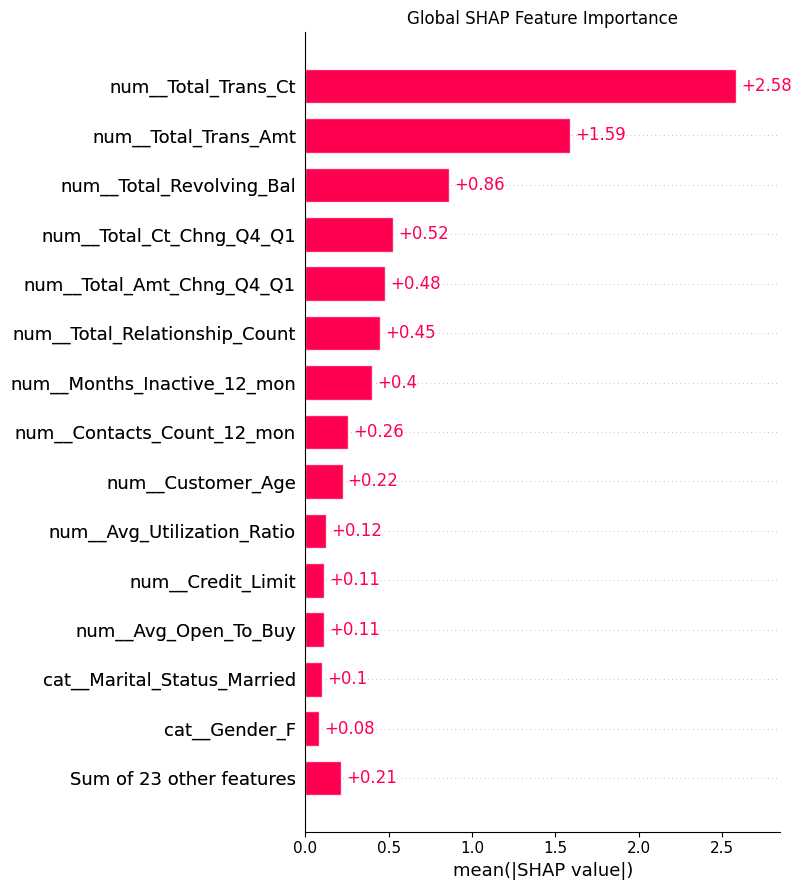

Saved: /Users/anshumaansharma0404gmail.com/Desktop/ML-Strugles/customer-churn-prediction/reports/figures/phase8_shap_global_feature_importance.png


In [6]:
global_bar_path = FIGURES_DIR / "phase8_shap_global_feature_importance.png"

plt.figure(figsize=(10, 7))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.savefig(global_bar_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", global_bar_path)


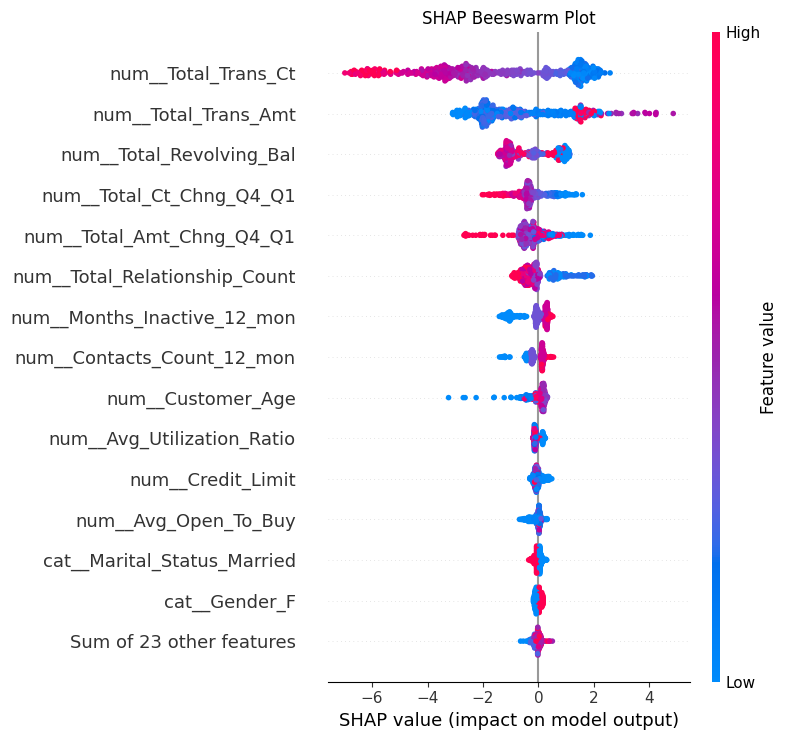

Saved: /Users/anshumaansharma0404gmail.com/Desktop/ML-Strugles/customer-churn-prediction/reports/figures/phase8_shap_beeswarm.png


In [7]:
beeswarm_path = FIGURES_DIR / "phase8_shap_beeswarm.png"

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.savefig(beeswarm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", beeswarm_path)


## 8.5 Local Explanation for One Customer

A local explanation shows why one specific customer received a particular churn score.

This is useful for customer retention teams because it can support targeted action rather than generic outreach.


In [8]:
probabilities = final_model.predict_proba(X_test)[:, 1]
local_customer_position = int(probabilities.argmax())

local_customer = X_test.iloc[[local_customer_position]]
local_probability = probabilities[local_customer_position]
local_prediction = final_model.predict(local_customer)[0]

local_shap_values = explain_binary_tree_model(final_model, local_customer)

print("Selected test row position:", local_customer_position)
print("Prediction:", int(local_prediction))
print(f"Churn probability: {local_probability:.4f}")


Selected test row position: 758
Prediction: 1
Churn probability: 0.9997


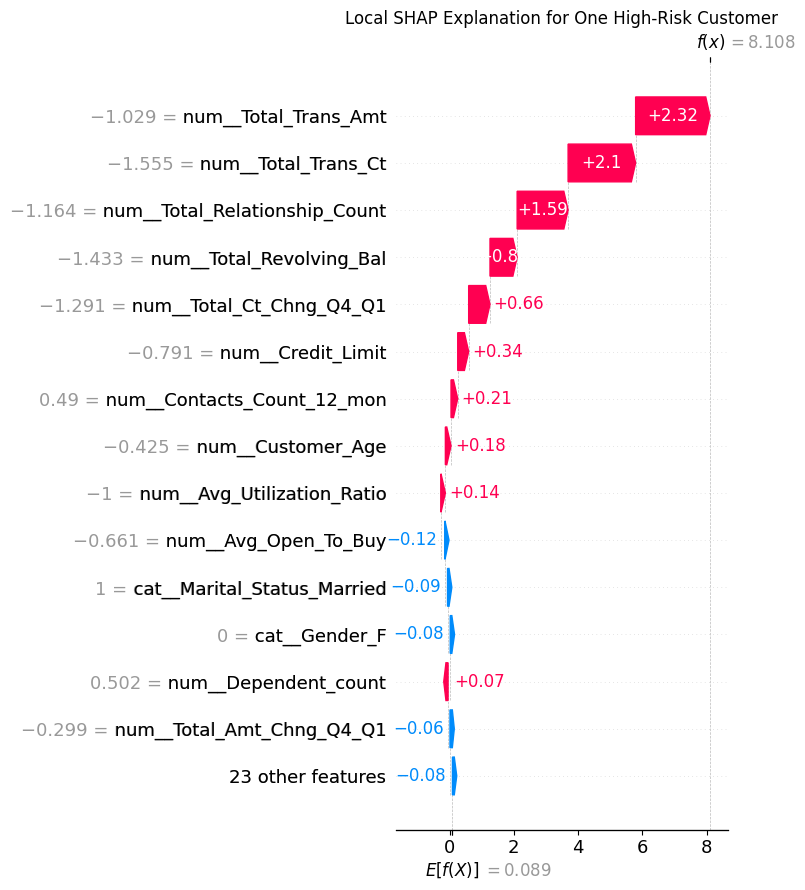

Saved: /Users/anshumaansharma0404gmail.com/Desktop/ML-Strugles/customer-churn-prediction/reports/figures/phase8_shap_local_customer_waterfall.png


In [9]:
local_waterfall_path = FIGURES_DIR / "phase8_shap_local_customer_waterfall.png"

plt.figure(figsize=(10, 7))
shap.plots.waterfall(local_shap_values[0], max_display=15, show=False)
plt.title("Local SHAP Explanation for One High-Risk Customer")
plt.tight_layout()
plt.savefig(local_waterfall_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", local_waterfall_path)


In [10]:
local_contributions = (
    pd.DataFrame(
        {
            "feature": local_shap_values.feature_names,
            "shap_value": local_shap_values.values[0],
            "feature_value": local_customer.iloc[0].values,
        }
    )
    .assign(abs_shap=lambda df: df["shap_value"].abs())
    .sort_values("abs_shap", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

local_contributions


,feature,shap_value,feature_value,abs_shap
0,num__Total_Trans_Amt,2.315897,-1.029428,2.315897
1,num__Total_Trans_Ct,2.102473,-1.554679,2.102473
2,num__Total_Relationship_Count,1.586528,-1.164234,1.586528
3,num__Total_Revolving_Bal,0.845220,-1.433246,0.845220
4,num__Total_Ct_Chng_Q4_Q1,0.664006,-1.291378,0.664006
5,num__Credit_Limit,0.340748,-0.790736,0.340748
6,num__Contacts_Count_12_mon,0.208419,0.489635,0.208419
7,num__Customer_Age,0.176195,-0.424577,0.176195
8,num__Avg_Utilization_Ratio,0.142753,-1.000072,0.142753
9,num__Avg_Open_To_Buy,-0.122584,-0.661453,0.122584


## 8.6 Business Interpretation

The top SHAP features show which processed customer attributes most influence churn predictions.

For business users, this helps translate model output into practical questions:

- Is customer activity declining?
- Is transaction behavior changing?
- Is the customer becoming inactive?
- Does the customer have low engagement with bank products?

SHAP does not prove causality, but it helps explain what the model is using to make predictions.


In [11]:
print("Top churn-driving features from SHAP:")
for rank, row in top_features_df.head(10).iterrows():
    print(f"{rank + 1}. {row['feature']} - mean |SHAP|: {row['mean_abs_shap']:.4f}")


Top churn-driving features from SHAP:
1. num__Total_Trans_Ct - mean |SHAP|: 2.5829
2. num__Total_Trans_Amt - mean |SHAP|: 1.5876
3. num__Total_Revolving_Bal - mean |SHAP|: 0.8614
4. num__Total_Ct_Chng_Q4_Q1 - mean |SHAP|: 0.5236
5. num__Total_Amt_Chng_Q4_Q1 - mean |SHAP|: 0.4775
6. num__Total_Relationship_Count - mean |SHAP|: 0.4485
7. num__Months_Inactive_12_mon - mean |SHAP|: 0.4003
8. num__Contacts_Count_12_mon - mean |SHAP|: 0.2569
9. num__Customer_Age - mean |SHAP|: 0.2232
10. num__Avg_Utilization_Ratio - mean |SHAP|: 0.1244


## Phase 8 Conclusion

SHAP explanations were generated for the final XGBoost model.

Saved plots:

```text
reports/figures/phase8_shap_global_feature_importance.png
reports/figures/phase8_shap_beeswarm.png
reports/figures/phase8_shap_local_customer_waterfall.png
```

These plots can be used in the portfolio project to explain both global model behavior and individual customer-level predictions.
